# Discrete Delta Hedging Analysis

### Libraries

In [1]:
import time
NOTEBOOK_START_TIME = time.time()
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent / 'src'))

In [2]:
from abc import ABC, abstractmethod
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from option import CallOption
from underlying import GeometricBrownianMotion
from delta_hedge import DeltaHedgingEngine

### Initialisation

In [4]:
np.random.seed(1973)
SAVE_FIGS = True

In [5]:
def plot_paths(hedging_results, path_index, png_filename, save_figs):
    _, axs = plt.subplots(2, 2, figsize=(10, 8))

    # Plot 1: Asset Price
    axs[0, 0].plot(hedging_results.time, hedging_results.underlying[path_index], color='navy', label="Asset Price")
    axs[0, 0].set_title("Sample Asset Path")
    axs[0, 0].set_xlabel("Years")
    axs[0, 0].set_ylabel("Price")
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    # Plot 2: Option Price
    axs[0, 1].plot(hedging_results.time, hedging_results.option[path_index], color='navy', label="Option Price")
    axs[0, 1].set_title("Sample Option Path")
    axs[0, 1].set_xlabel("Years")
    axs[0, 1].set_ylabel("Price")
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    # Plot 3: Delta and Approx Delta
    axs[1, 0].plot(hedging_results.time, hedging_results.true_delta[path_index], color='navy', label="Delta")
    axs[1, 0].plot(hedging_results.time, hedging_results.approx_delta[path_index], color='red', label="Approx Delta")
    axs[1, 0].set_title("Sample Delta Path with Approximation")
    axs[1, 0].set_xlabel("Years")
    axs[1, 0].set_ylabel("Delta")
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    # Plot 4: Gamma
    # Gamma tends to zero at maturity if the option is deep ITM/OTM. Gamma blows up at maturity if ATM.
    axs[1, 1].plot(hedging_results.time, hedging_results.gamma[path_index], color='navy', label="Gamma")
    axs[1, 1].set_title("Sample Gamma Path")
    axs[1, 1].set_xlabel("Years")
    axs[1, 1].set_ylabel("Gamma")
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Save the figure if needed
    if save_figs:
        plt.savefig(f'../figures/{png_filename}.png')
    

Market parameters:

In [6]:
SPOT = 100 # $100
STRIKE = 100 # $100
MATURITY = 1 # 1 year
RATE = 0.05 # 5%
VOLATILITY = 0.2 # 20%

Graphing parameters:

In [7]:
RUNS = 1000

Market objects:

In [8]:
option = CallOption(STRIKE, MATURITY)

### Pathwise Plots Of Delta Hedging

Run Simulation...

In [9]:
mesh = 1/10
drift = 0.1
asset = GeometricBrownianMotion(SPOT, drift, VOLATILITY)
results = DeltaHedgingEngine(option, asset).run(RATE, VOLATILITY, RUNS, mesh)

Deep in-the-money

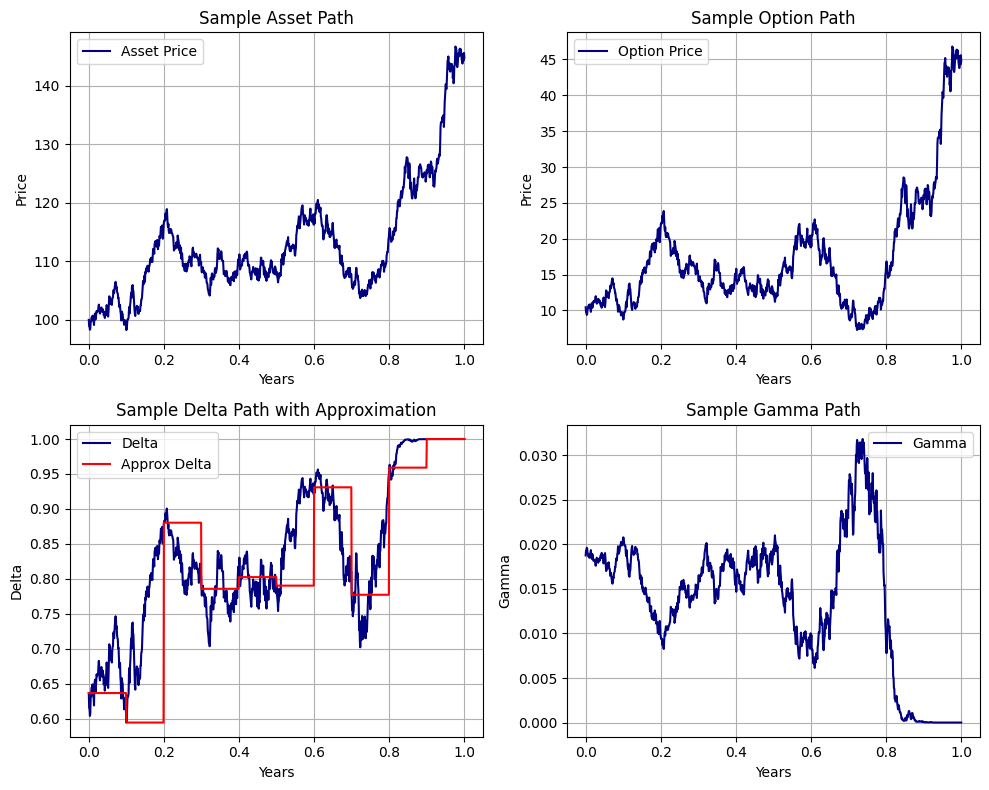

In [10]:
plot_paths(results, 0, 'paths_deepITM', SAVE_FIGS)

Deep out-the-money

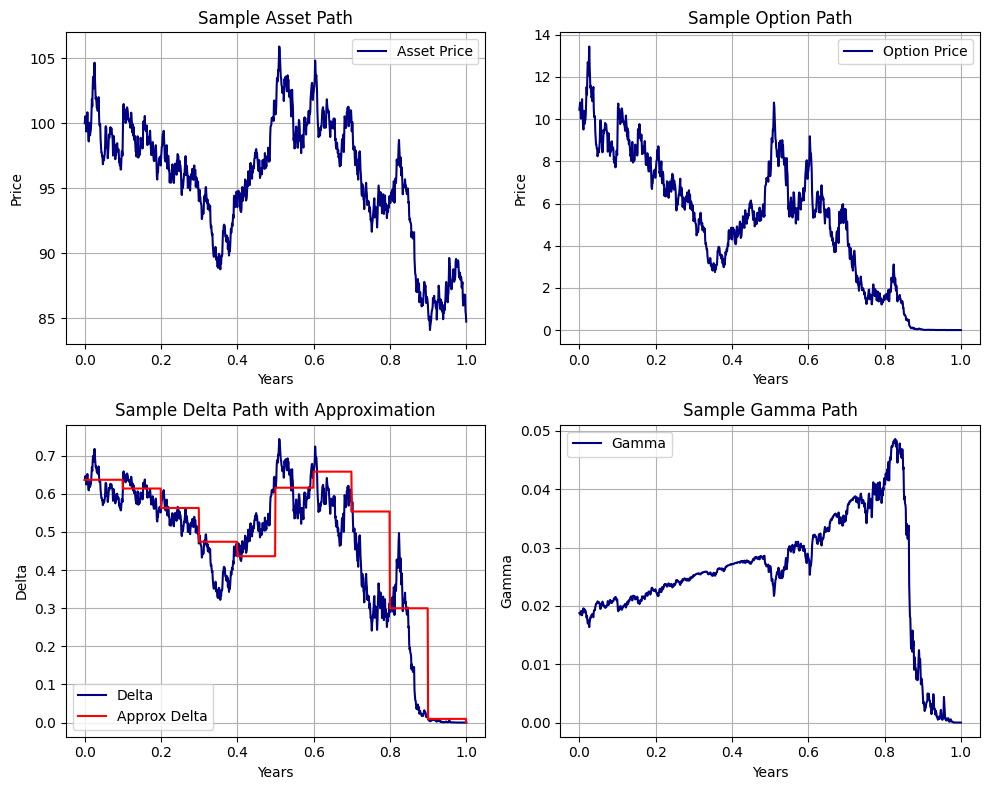

In [11]:
plot_paths(results, 3, 'paths_OTM', SAVE_FIGS)

At-the-money

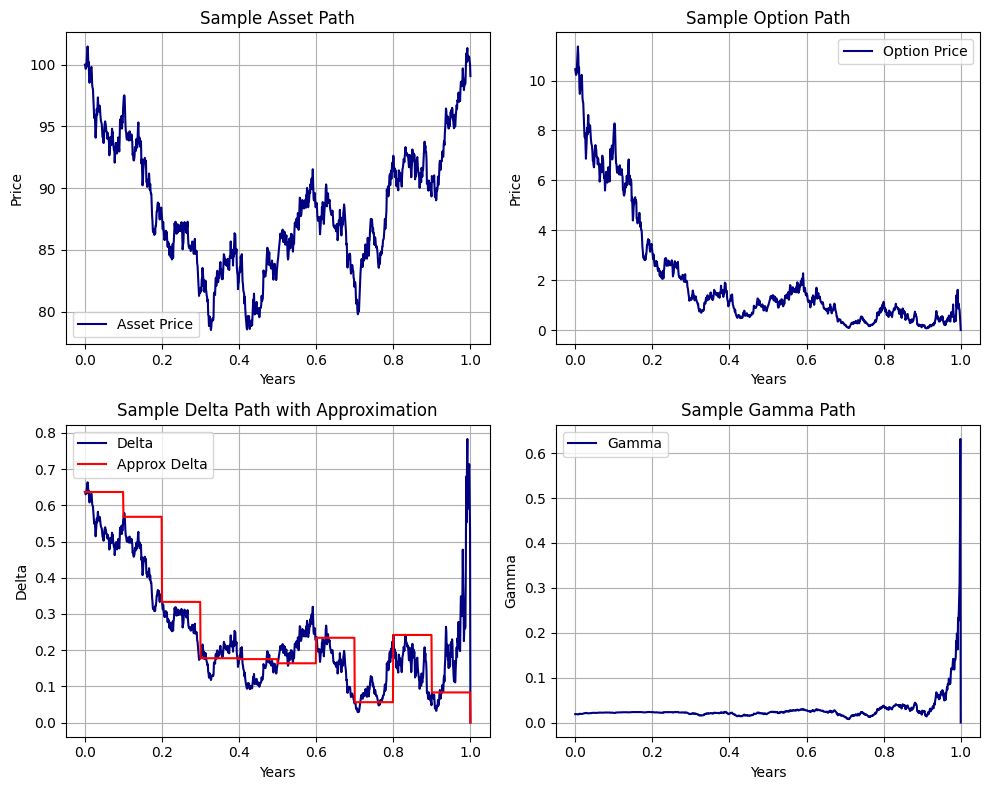

In [12]:
plot_paths(results, 4, 'paths_ATM', SAVE_FIGS)

In-the-money

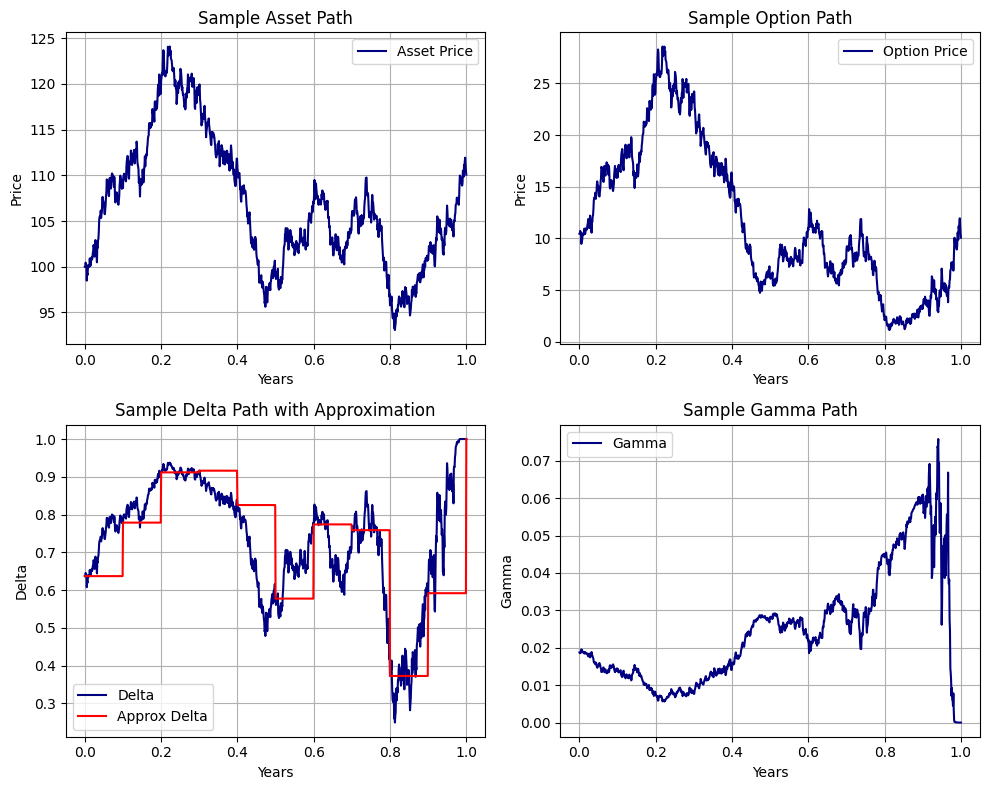

In [13]:
plot_paths(results, 7, 'paths_ITM', SAVE_FIGS)

### Portfolio Profit & Loss With Control Group

Run simulation...

In [14]:
mesh = 1/100
drift = 0.5
asset = GeometricBrownianMotion(SPOT, drift, VOLATILITY)
results = DeltaHedgingEngine(option, asset).run(RATE, VOLATILITY, RUNS, mesh)

Control group (no hedging):

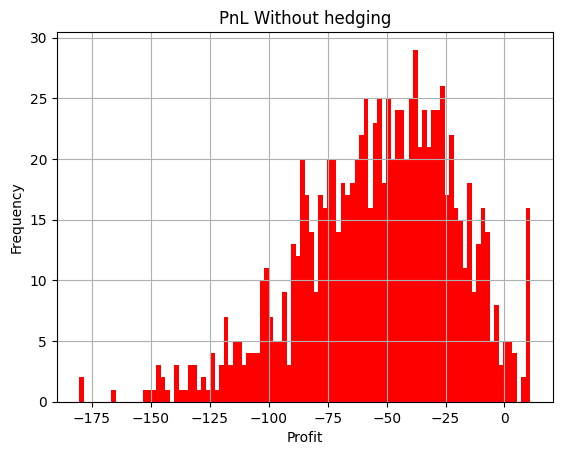

In [15]:
current_asset_price = np.zeros(RUNS)
current_asset_price[:] = asset.simulate(MATURITY, RUNS, mesh)[:,0]
final_asset_price = np.zeros(RUNS)
final_asset_price[:] = asset.simulate(MATURITY, RUNS, mesh)[:,-1]
no_hedge_pnl = option.price(current_asset_price, 0, RATE, VOLATILITY)*np.exp(RATE*MATURITY) - option.payoff(final_asset_price)

plt.hist(no_hedge_pnl, bins=100, density=False, color='red')

plt.title("PnL Without hedging")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.grid(True)
if SAVE_FIGS:
    plt.savefig('../figures/PnL_without_hedge.png')

Delta hedged portfolio:

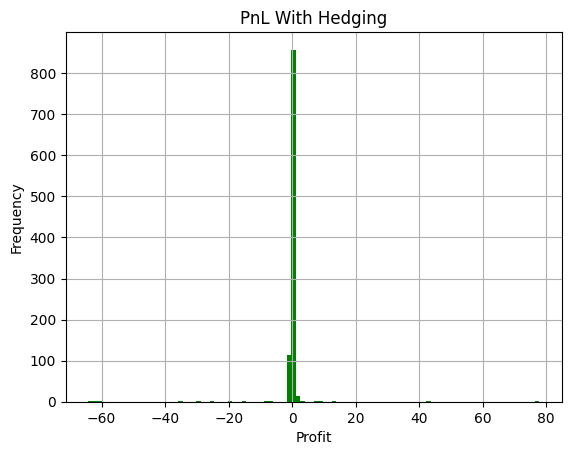

In [16]:
plt.hist(results.pnl, bins=100, density=False, color='green')

plt.title("PnL With Hedging")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.grid(True)
if SAVE_FIGS:
    plt.savefig('../figures/PnL_with_hedge.png')

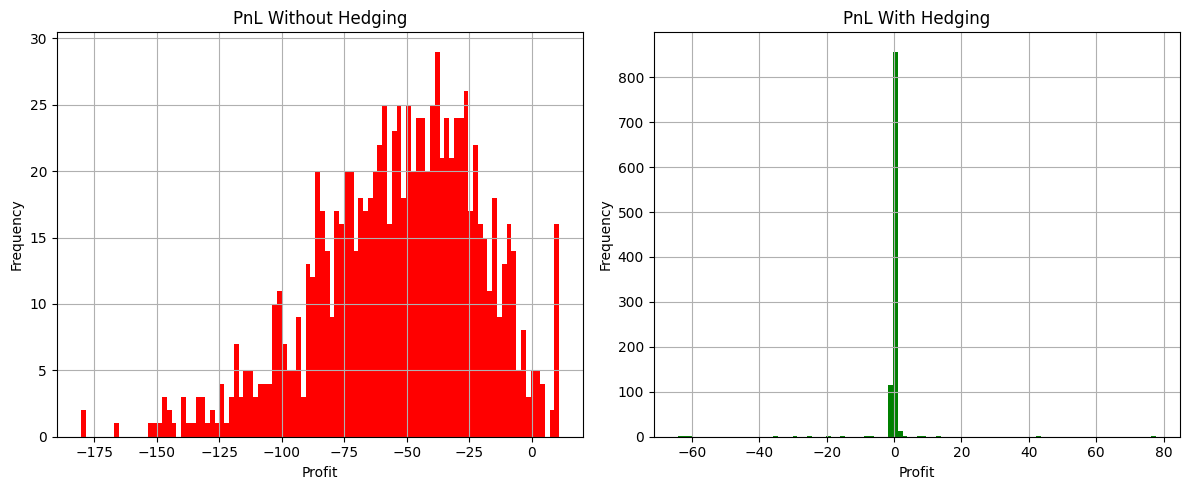

In [17]:
_, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].hist(no_hedge_pnl, bins=100, density=False, color='red')
axs[0].set_title("PnL Without Hedging")
axs[0].set_xlabel("Profit")
axs[0].set_ylabel("Frequency")
axs[0].grid(True)

axs[1].hist(results.pnl, bins=100, density=False, color='green')
axs[1].set_title("PnL With Hedging")
axs[1].set_xlabel("Profit")
axs[1].set_ylabel("Frequency")
axs[1].grid(True)

plt.tight_layout()

if SAVE_FIGS:
    plt.savefig('../figures/PnL_with_vs_without_hedge.png')

Summary statistics:

In [18]:
print(f'No hedging: Mean PnL= {np.mean(no_hedge_pnl):.2f}, Stddev PnL= {np.std(no_hedge_pnl):.6f}')
print(f'Hedging: Mean PnL= {np.mean(results.pnl):.2f}, Stddev PnL= {np.std(results.pnl):.6f}')

No hedging: Mean PnL= -53.18, Stddev PnL= 32.794346
Hedging: Mean PnL= -0.07, Stddev PnL= 4.851485


### Convergence Test

Estimated convergence rate: 0.529


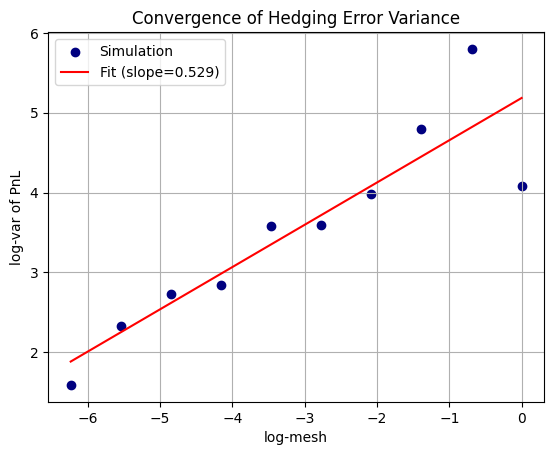

In [19]:
dt_array = 1 / (2 ** np.arange(10))
variance_list = []

for dt in dt_array:
    results = DeltaHedgingEngine(option, asset).run(RATE, VOLATILITY, RUNS, dt, random_seed=1973)
    variance_list.append(np.var(results.pnl))

log_dt = np.log(dt_array)
log_var = np.log(np.array(variance_list))

slope, intercept = np.polyfit(log_dt, log_var, 1)

print(f"Estimated convergence rate: {slope:.3f}")

plt.scatter(log_dt, log_var, color='navy', label="Simulation")
plt.plot(log_dt, slope*log_dt + intercept, color='red', label=f"Fit (slope={slope:.3f})")

plt.title("Convergence of Hedging Error Variance")
plt.xlabel("log-mesh")
plt.ylabel("log-var of PnL")
plt.legend()
plt.grid(True)
if SAVE_FIGS:
    plt.savefig('../figures/loglog_plot_of_error_vs_dt.png')

### Independence of Drift

Correlation between drift and PnL variance: 0.055323


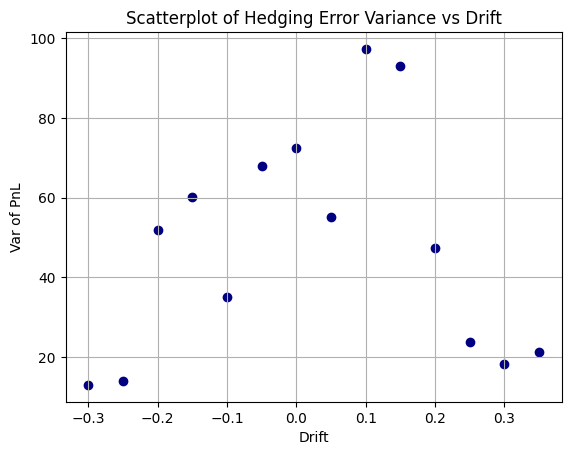

In [20]:
mu_values = [round(x, 2) for x in np.arange(-0.3, 0.351, 0.05)]
pnl_var = []
mesh = 1/1000

for mu in mu_values:
    results = DeltaHedgingEngine(option, GeometricBrownianMotion(SPOT, mu, VOLATILITY)).run(RATE, VOLATILITY, RUNS, mesh, random_seed=1973)
    pnl_var.append(np.var(results.pnl))

mu_arr = np.array(mu_values)
var_arr = np.array(pnl_var)

correlation = np.corrcoef(mu_arr, var_arr)[0, 1]
print(f"Correlation between drift and PnL variance: {correlation:.6f}")

plt.scatter(mu_arr, var_arr, color='navy')

plt.title("Scatterplot of Hedging Error Variance vs Drift")
plt.xlabel("Drift")
plt.ylabel("Var of PnL")
plt.grid(True)
if SAVE_FIGS:
    plt.savefig('../figures/error_vs_drift.png')

In [21]:
NOTEBOOK_END_TIME = time.time()
ELAPSED_TIME = NOTEBOOK_END_TIME - NOTEBOOK_START_TIME
print(f"Notebook took {ELAPSED_TIME:.3f} seconds to run!")

Notebook took 23.632 seconds to run!
